## House Price Prediction using SVM, RandomForest, LinearRegression in Sklearn

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading Dataset

In [2]:
!wget https://raw.githubusercontent.com/fatahrahimi330/100-Machine-Learning-Projects/master/37-House%20Price%20Prediction/HousePricePrediction.xlsx

--2026-03-23 05:52:58--  https://raw.githubusercontent.com/fatahrahimi330/100-Machine-Learning-Projects/master/37-House%20Price%20Prediction/HousePricePrediction.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 219098 (214K) [application/octet-stream]
Saving to: ‘HousePricePrediction.xlsx’

HousePricePredictio 100%[===================>] 213.96K  --.-KB/s    in 0.02s   

2026-03-23 05:52:58 (8.59 MB/s) - ‘HousePricePrediction.xlsx’ saved [219098/219098]



In [3]:
df = pd.read_excel('HousePricePrediction.xlsx')
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [4]:
df.shape

(2919, 13)

In [5]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [7]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,1


In [8]:
object_cols = df.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_cols))

int_col = df.select_dtypes(include=['int64']).columns
print("Integer variables:", len(int_col))

fl_cols = df.select_dtypes(include=['float64']).columns
print("Float variables:", len(fl_cols))

Categorical variables: 4
Integer variables: 6
Float variables: 3


Heatmap saved as correlation_heatmap.png


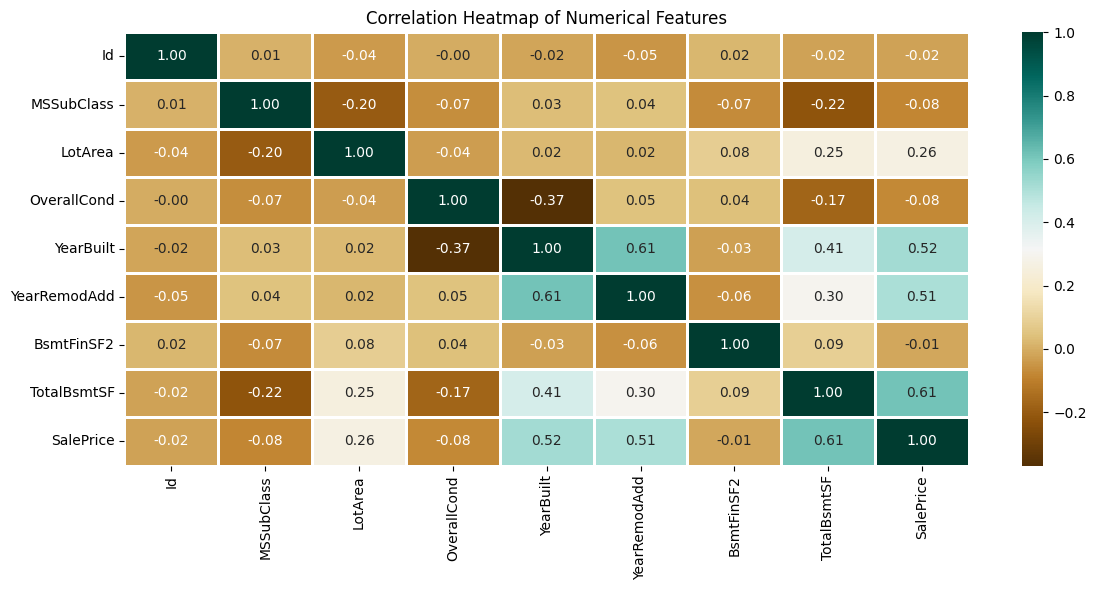

In [9]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_df.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

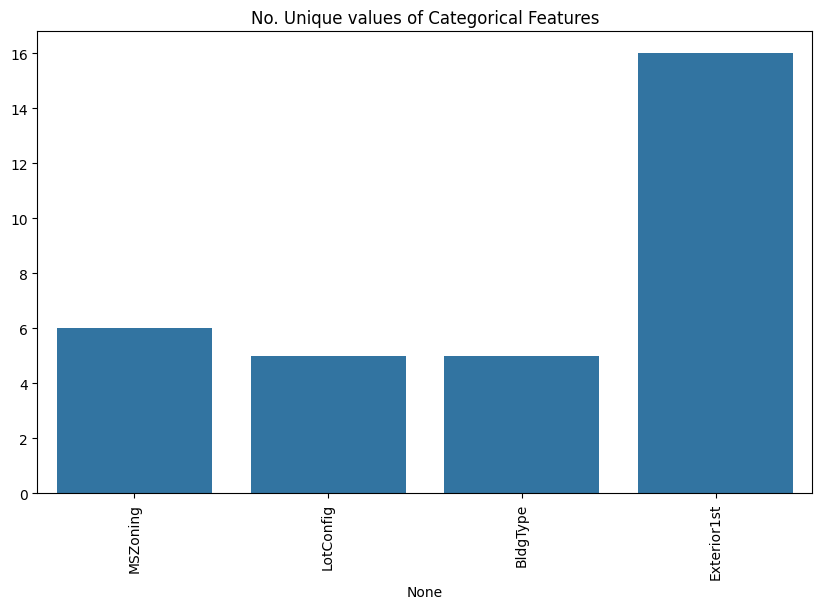

In [11]:
unique_values = []
for col in object_cols:
  unique_values.append(df[col].unique().size)
plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)
plt.show()

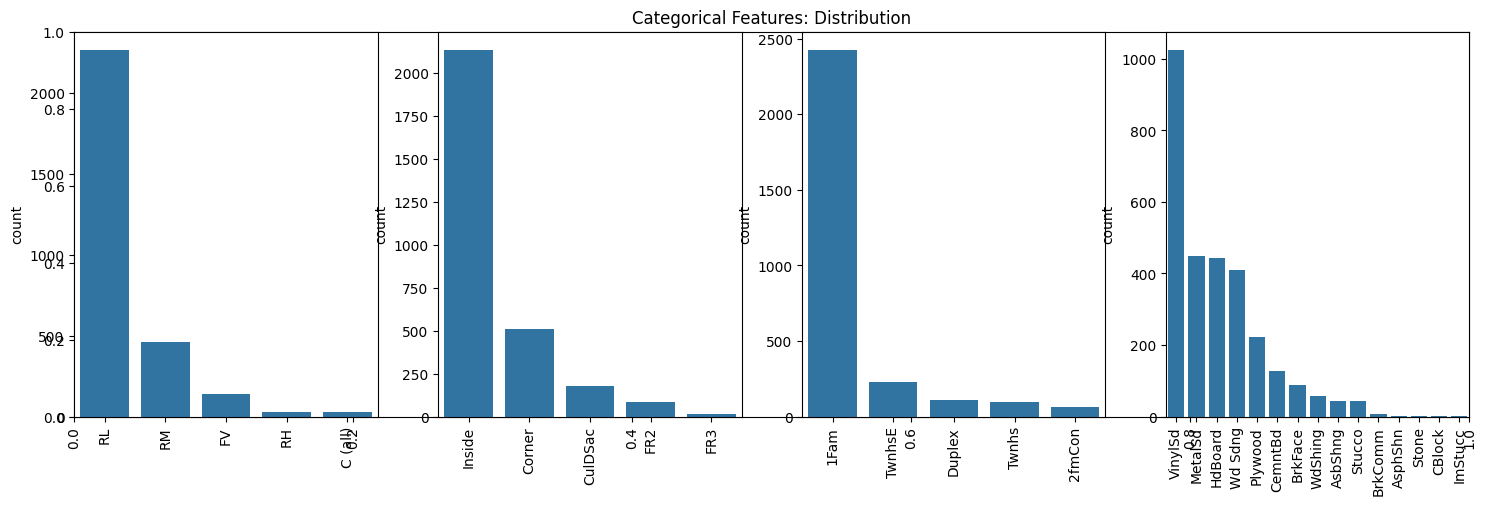

In [14]:
plt.figure(figsize=(18, 5))
plt.title('Categorical Features: Distribution')
plt.xticks(rotation=90)
index = 1

for col in object_cols:
    y = df[col].value_counts()
    plt.subplot(1, 4, index)
    plt.xticks(rotation=90)
    sns.barplot(x=list(y.index), y=y)
    index += 1

2. Data Cleaning

In [15]:
df.drop(['Id'], axis=1, inplace=True)

In [16]:
df['SalePrice'] = df['SalePrice'].fillna(df['SalePrice'].mean())

In [17]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,4
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,1
BsmtFinSF2,1


In [18]:
df = df.dropna()

In [19]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,0
BsmtFinSF2,0


3. Feature Encoding

In [21]:
from sklearn.preprocessing import OneHotEncoder

s = (df.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('Number of categorical features: ', len(object_cols))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
Number of categorical features:  4


In [22]:
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(df[object_cols]))
OH_cols.index = df.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = df.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

In [23]:
df_final.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_C (all),MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,208500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60,11250,5,2001,2002,0.0,920.0,223500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,70,9550,5,1915,1970,0.0,756.0,140000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [24]:
df.shape

(2913, 12)

4. Train Test Split

In [25]:
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
y = df_final['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

### 4. Build and Fit the Models

In [33]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

models = [
    SVR(), RandomForestRegressor(), LinearRegression()
]

for model in range(len(models)):
    models[model].fit(X_train, y_train)
    train_pred = models[model].predict(X_train)
    error = mean_absolute_percentage_error(y_train, train_pred)
    print(f"{models[model].__class__.__name__}---> Training Error: {error:.3f} ")
    print()

SVR---> Training Error: 0.181 

RandomForestRegressor---> Training Error: 0.071 

LinearRegression---> Training Error: 0.188 



### 5. Make Prediction

In [34]:
for model in range(len(models)):
    test_pred = models[model].predict(X_test)
    print(f"{models[model].__class__.__name__}: ")
    print(f"Actual: {y_test.iloc[0]:.3f} \nPredicted: {test_pred[0]:.3f}")
    print()

SVR: 
Actual: 180921.196 
Predicted: 180921.099

RandomForestRegressor: 
Actual: 180921.196 
Predicted: 182715.826

LinearRegression: 
Actual: 180921.196 
Predicted: 191650.159



### 6. Evaluate the Models

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

results = []
predictions = {}

for model in models:
    model_name = model.__class__.__name__
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2 Score': r2
    })

results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df)


,Model,MAE,RMSE,MAPE,R2 Score
2,LinearRegression,30829.936664,41138.555717,0.187417,0.374142
1,RandomForestRegressor,30316.370730,42268.774264,0.184581,0.339281
0,SVR,28848.681204,52000.902138,0.187051,0.000002


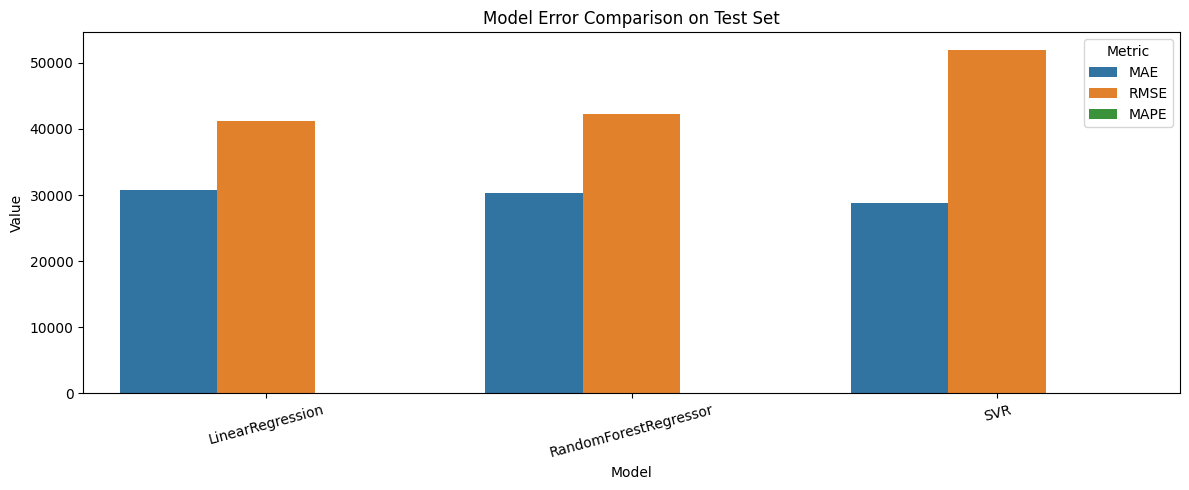

/tmp/ipykernel_438/171846392.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R2 Score', palette='viridis')


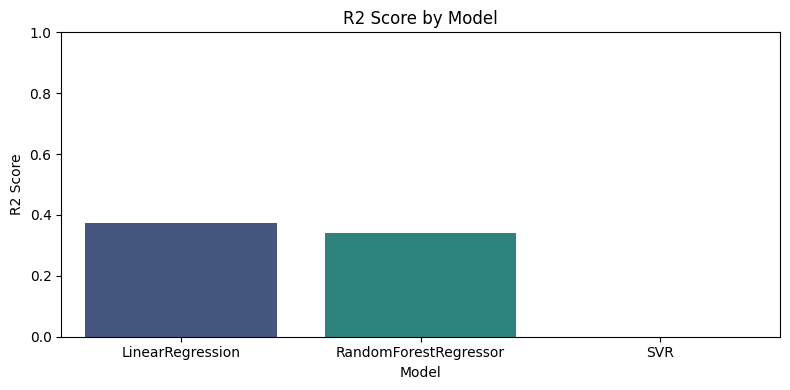

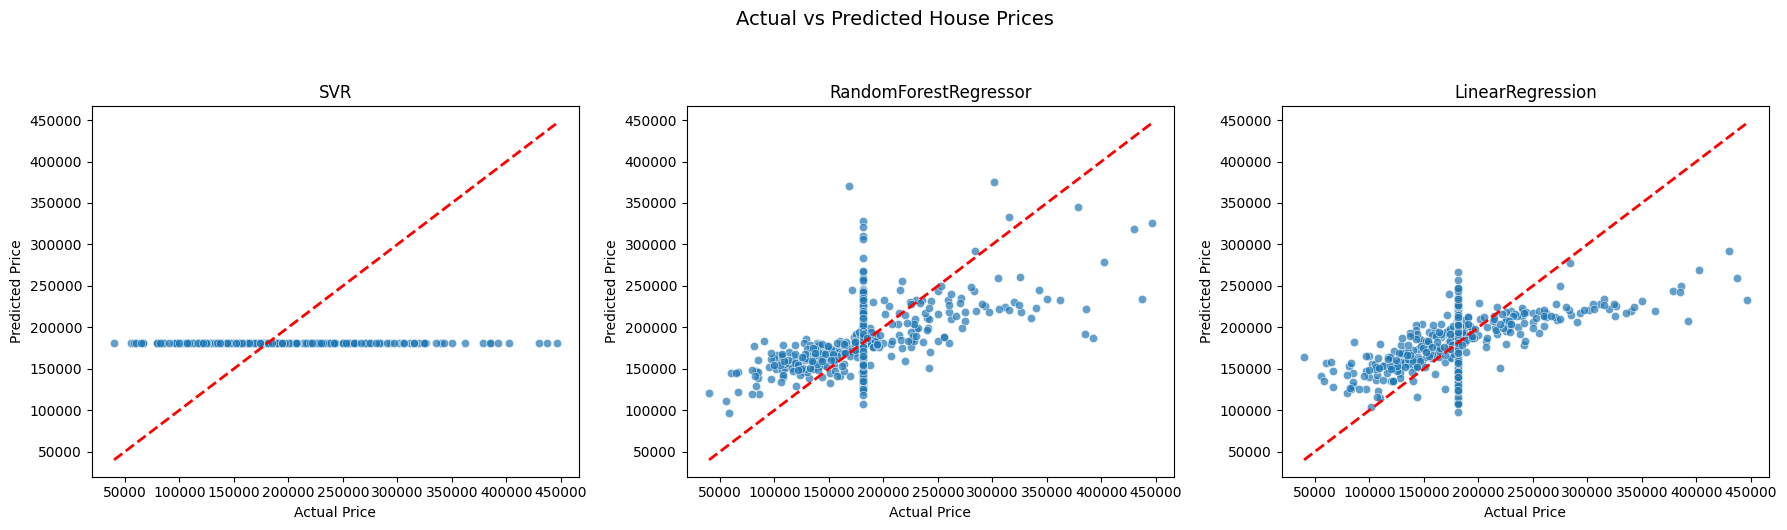

In [36]:

# ---- Plot 1: Metric comparison ----
plt.figure(figsize=(12, 5))
melted = results_df.melt(id_vars='Model', value_vars=['MAE', 'RMSE', 'MAPE'],
                         var_name='Metric', value_name='Value')
sns.barplot(data=melted, x='Model', y='Value', hue='Metric')
plt.title('Model Error Comparison on Test Set')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ---- Plot 2: R2 score comparison ----
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='Model', y='R2 Score', palette='viridis')
plt.title('R2 Score by Model')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ---- Plot 3: Actual vs Predicted scatter ----
n_models = len(predictions)
plt.figure(figsize=(6 * n_models, 5))

for i, (model_name, y_pred) in enumerate(predictions.items(), 1):
    plt.subplot(1, n_models, i)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(model_name)

plt.suptitle('Actual vs Predicted House Prices', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()